In [1]:
import torch

acts = torch.load("musicgen_activations.pt")

print(acts.keys())  # layer names
for layer, tensors in acts.items():
    print(layer, "has", len(tensors), "calls")
    print("  first tensor shape:", tensors[0].shape)
    break

/tmp/ipykernel_1747335/1985543291.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  acts = torch.load("musicgen_activations.pt")


dict_keys(['lm_block_0', 'lm_block_1', 'lm_block_2', 'lm_block_3', 'lm_block_4', 'lm_block_5', 'lm_block_6', 'lm_block_7', 'lm_block_8', 'lm_block_9', 'lm_block_10', 'lm_block_11', 'lm_block_12', 'lm_block_13', 'lm_block_14', 'lm_block_15', 'lm_block_16', 'lm_block_17', 'lm_block_18', 'lm_block_19', 'lm_block_20', 'lm_block_21', 'lm_block_22', 'lm_block_23'])
lm_block_0 has 403 calls
  first tensor shape: torch.Size([4, 1, 1024])


In [2]:
acts

{'lm_block_0': [tensor([[[0.9204, 1.2956, 1.0377,  ..., 0.4496, 0.3747, 0.3996]],
  
          [[0.9208, 1.2962, 1.0363,  ..., 0.4486, 0.3748, 0.4001]],
  
          [[0.9169, 1.2936, 1.0298,  ..., 0.4425, 0.3684, 0.3948]],
  
          [[0.9169, 1.2936, 1.0298,  ..., 0.4425, 0.3684, 0.3948]]]),
  tensor([[[0.6498, 0.7286, 0.5139,  ..., 0.4840, 0.3175, 0.4465]],
  
          [[0.6488, 0.7282, 0.5152,  ..., 0.4484, 0.3233, 0.3879]],
  
          [[0.6465, 0.7265, 0.5059,  ..., 0.4768, 0.3113, 0.4416]],
  
          [[0.6452, 0.7255, 0.5088,  ..., 0.4424, 0.3172, 0.3826]]]),
  tensor([[[-0.1503, -0.1703, -0.3174,  ...,  0.4335,  0.3427,  0.4705]],
  
          [[-0.1455, -0.1657, -0.3243,  ...,  0.4217,  0.3547,  0.3353]],
  
          [[-0.1533, -0.1723, -0.3253,  ...,  0.4260,  0.3366,  0.4657]],
  
          [[-0.1488, -0.1684, -0.3307,  ...,  0.4153,  0.3484,  0.3297]]]),
  tensor([[[-0.5733, -0.6916, -0.8293,  ...,  0.3875,  0.3974,  0.4947]],
  
          [[-0.5415, -0.6791, -0.822

In [4]:
import numpy as np

layer = "lm_block_0"
layer_acts = torch.cat(acts[layer], dim=1)
print(layer_acts.shape)
layer_np = layer_acts.numpy()

torch.Size([4, 403, 1024])


In [5]:
print(layer_acts.mean().item(), layer_acts.std().item())

0.3640715181827545 0.38597074151039124


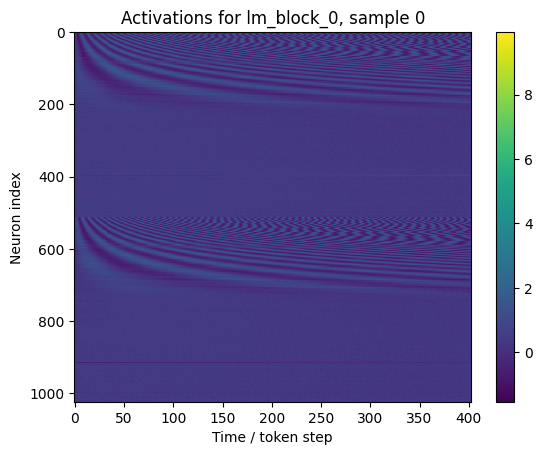

In [6]:
import matplotlib.pyplot as plt

layer = "lm_block_0"
layer_acts = torch.cat(acts[layer], dim=1)  # [batch, time, d_model]
one = layer_acts[0]                         # [time, d_model]

plt.imshow(one.T, aspect="auto", interpolation="nearest")
plt.xlabel("Time / token step")
plt.ylabel("Neuron index")
plt.title(f"Activations for {layer}, sample 0")
plt.colorbar()
plt.show()